# Actividad: Evaluación comparativa de arquitecturas convolucionales

Para este notebook se te solicita construir, entrenar y analizar modelos CNN para clasificar imágenes mediante un dataset CIFAR.

**Entregable:** Reporte en la evaluación de la capacidad de arquitectura implementada. Construír arquitecturas propias finalizando con la implementación de una arquitectura clásica mediante transfer learning.


## Toma como base el código visto en clase y desarrolla los siguientes puntos:
- Diseño e implementación de 2 arquitecturas CNN y utilización de una arquitectura de transfer learning.

- Buen uso de data augmentation y regularización.

- Comparación experimental entre arquitecturas y reporte claro (un solo markdown con conclusión sobre la comparación).





# *Importacion de Librerias*

In [2]:
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications import VGG16, ResNet50, MobileNetV2


# *Preparacion y exploracion de datos*

In [3]:
print(sys.executable)

c:\Users\JGMRo\venvs\cnn311\Scripts\python.exe


In [4]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

In [5]:
print (x_train.shape)
print (y_train.shape)
print (x_test.shape)
print (y_test.shape)


(50000, 32, 32, 3)
(50000, 1)
(10000, 32, 32, 3)
(10000, 1)


In [6]:
print (x_train.dtype)
print (y_train.dtype)
print (x_train.max())
print (x_train.min())
print (y_train.max())
print (y_train.min())
print (np.unique(y_train, return_counts=True))

uint8
uint8
255
0
9
0
(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8), array([5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000],
      dtype=int64))


In [7]:
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, stratify = y_train, test_size=0.2, random_state=42)

In [8]:
print (x_train.shape)
print (y_train.shape)
print (x_test.shape)
print (y_test.shape)
print (x_val.shape)
print (y_val.shape)

(40000, 32, 32, 3)
(40000, 1)
(10000, 32, 32, 3)
(10000, 1)
(10000, 32, 32, 3)
(10000, 1)


# *Aumento de datos* 

In [9]:
data_argumentation = keras.Sequential([
    keras.layers.RandomFlip(mode= "horizontal"),
    keras.layers.RandomTranslation(height_factor = 0.1, width_factor = 0.1)
])

In [10]:
imagen_original = x_train[0]
imagen_aumentada = data_argumentation(imagen_original,training=True)


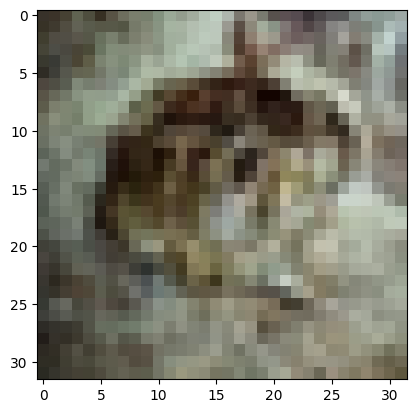

In [19]:
plt.imshow(imagen_original)


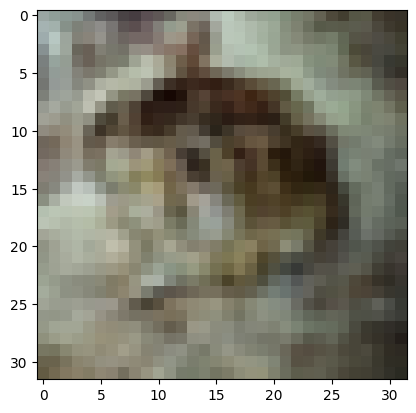

In [12]:
plt.imshow(imagen_aumentada/255)

## Definiciones de modelos

*Modelo 1*

In [13]:
# Recuerda aquí solo generar las arquitecturas, cada capa así como sus neuronas.
def crear_Modelo():
    modelo = keras.Sequential ([
keras.Input(shape=(32,32,3)),
data_argumentation,
keras.layers.Rescaling(scale=1/255),
keras.layers.Conv2D(filters=32,kernel_size=(3,3),padding ="same",activation ="relu"),
keras.layers.MaxPooling2D(pool_size=(2,2),strides=(2,2)),
keras.layers.Conv2D(filters=64,kernel_size=(3,3),padding ="same",activation ="relu"),
keras.layers.MaxPooling2D(pool_size=(2,2),strides=(2,2)),
keras.layers.Flatten(),
keras.layers.Dense(units=128,activation="relu"),
keras.layers.Dropout(rate=0.5),
keras.layers.Dense(units=10,activation="softmax")
    ])
    return modelo
modelo = crear_Modelo()
modelo.summary()


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential (Sequential)     (32, 32, 3)               0         
                                                                 
 rescaling (Rescaling)       (None, 32, 32, 3)         0         
                                                                 
 conv2d (Conv2D)             (None, 32, 32, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 16, 16, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 16, 16, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 8, 8, 64)          0         
 g2D)                                                

*Model 2*

In [14]:
def crear_Modelo2():
    modelo2 = keras.Sequential ([
keras.Input(shape=(32,32,3)),
data_argumentation,
keras.layers.Rescaling(scale=1/255),
keras.layers.Conv2D(filters=32,kernel_size=(3,3),padding ="same",activation ="relu"),
keras.layers.MaxPooling2D(pool_size=(2,2),strides=(2,2)),
keras.layers.Conv2D(filters=64,kernel_size=(3,3),padding ="same",activation ="relu"),
keras.layers.MaxPooling2D(pool_size=(2,2),strides=(2,2)),
keras.layers.Conv2D(filters=128,kernel_size=(3,3),padding ="same",activation ="relu"),
keras.layers.MaxPooling2D(pool_size=(2,2),strides=(2,2)),
keras.layers.GlobalAveragePooling2D(),
keras.layers.Dense(units=128,activation="relu"),
keras.layers.Dropout(rate=0.5),
keras.layers.Dense(units=10,activation="softmax")
    ])
    return modelo2
modelo2 = crear_Modelo2()
modelo2.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential (Sequential)     (32, 32, 3)               0         
                                                                 
 rescaling_1 (Rescaling)     (None, 32, 32, 3)         0         
                                                                 
 conv2d_2 (Conv2D)           (None, 32, 32, 32)        896       
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 16, 16, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_3 (Conv2D)           (None, 16, 16, 64)        18496     
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 8, 8, 64)          0         
 g2D)                                                 

In [15]:
base_mobilenet = MobileNetV2(weights="imagenet", include_top=False, input_shape=(96,96,3))
base_mobilenet.trainable=False
base_mobilenet.summary()

Model: "mobilenetv2_1.00_96"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_3 (InputLayer)        [(None, 96, 96, 3)]          0         []                            
                                                                                                  
 Conv1 (Conv2D)              (None, 48, 48, 32)           864       ['input_3[0][0]']             
                                                                                                  
 bn_Conv1 (BatchNormalizati  (None, 48, 48, 32)           128       ['Conv1[0][0]']               
 on)                                                                                              
                                                                                                  
 Conv1_relu (ReLU)           (None, 48, 48, 32)           0         ['bn_Conv1[0

*Modelo 3*

In [16]:
def crear_Modelo3 ():
    modelo3 = keras.Sequential ([
keras.Input(shape=(32,32,3)),
data_argumentation,
keras.layers.Resizing(height=96,width=96),
keras.layers.Rescaling(scale=1/127.5, offset=-1),
base_mobilenet,
keras.layers.GlobalAveragePooling2D(),
keras.layers.Dropout(rate=0.5),
keras.layers.Dense(units=10,activation="softmax")
    ])
    return modelo3
modelo3 = crear_Modelo3()
modelo3.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential (Sequential)     (32, 32, 3)               0         
                                                                 
 resizing (Resizing)         (None, 96, 96, 3)         0         
                                                                 
 rescaling_2 (Rescaling)     (None, 96, 96, 3)         0         
                                                                 
 mobilenetv2_1.00_96 (Funct  (None, 3, 3, 1280)        2257984   
 ional)                                                          
                                                                 
 global_average_pooling2d_1  (None, 1280)              0         
  (GlobalAveragePooling2D)                                       
                                                                 
 dropout_2 (Dropout)         (None, 1280)             

## Entrenamiento de modelos.

*Compilar modelo 1*

In [17]:
# Aquí agrega la compilación y entrenamiento de las arquitecturas generadas.
modelo.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

*Compilar Modelo 2*

In [18]:
# Aquí agrega la compilación y entrenamiento de las arquitecturas generadas.
modelo2.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

*Compilar Modelo 3*

In [19]:
# Aquí agrega la compilación y entrenamiento de las arquitecturas generadas.
modelo3.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

In [20]:
parada_1 = keras.callbacks.EarlyStopping(monitor="val_loss", mode="min", patience= 3, restore_best_weights=True)

In [21]:

inicio_1 = time.perf_counter()
historial_1 = modelo.fit(x_train,y_train, validation_data=(x_val, y_val), epochs= 20, batch_size=64, callbacks=[parada_1])
tiempo_1 = time.perf_counter() - inicio_1

Epoch 1/20


625/625 [==============================] - 46s 70ms/step - loss: 1.7835 - accuracy: 0.3413 - val_loss: 1.4265 - val_accuracy: 0.4947
Epoch 2/20
625/625 [==============================] - 41s 65ms/step - loss: 1.5024 - accuracy: 0.4543 - val_loss: 1.2272 - val_accuracy: 0.5698
Epoch 3/20
625/625 [==============================] - 47s 75ms/step - loss: 1.3845 - accuracy: 0.5038 - val_loss: 1.1532 - val_accuracy: 0.5881
Epoch 4/20
625/625 [==============================] - 51s 81ms/step - loss: 1.3091 - accuracy: 0.5314 - val_loss: 1.0895 - val_accuracy: 0.6174
Epoch 5/20
625/625 [==============================] - 48s 77ms/step - loss: 1.2558 - accuracy: 0.5508 - val_loss: 1.0394 - val_accuracy: 0.6340
Epoch 6/20
625/625 [==============================] - 42s 67ms/step - loss: 1.2234 - accuracy: 0.5631 - val_loss: 1.0945 - val_accuracy: 0.6199
Epoch 7/20
625/625 [==============================] - 37s 60ms/step - loss: 1.1988 - accuracy: 0.5758 - val_loss: 0.9467 - val_accurac

In [22]:
print(tiempo_1)

437.1061084999237


In [23]:
len(historial_1.history["loss"])

10

In [24]:
np.argmin(historial_1.history["val_loss"]) + 1

7

In [25]:
parada_2 = keras.callbacks.EarlyStopping(monitor="val_loss", mode="min", patience= 3, restore_best_weights=True)

In [26]:
inicio_2 = time.perf_counter()
historial_2 = modelo2.fit(x_train,y_train, validation_data=(x_val, y_val), epochs= 20, batch_size=64, callbacks=[parada_2])
tiempo_2 = time.perf_counter() - inicio_2

Epoch 1/20
625/625 [==============================] - 54s 82ms/step - loss: 1.9135 - accuracy: 0.2728 - val_loss: 1.6142 - val_accuracy: 0.3936
Epoch 2/20
625/625 [==============================] - 48s 77ms/step - loss: 1.6411 - accuracy: 0.3867 - val_loss: 1.4693 - val_accuracy: 0.4471
Epoch 3/20
625/625 [==============================] - 40s 64ms/step - loss: 1.5070 - accuracy: 0.4475 - val_loss: 1.3532 - val_accuracy: 0.4935
Epoch 4/20
625/625 [==============================] - 51s 82ms/step - loss: 1.4200 - accuracy: 0.4837 - val_loss: 1.2476 - val_accuracy: 0.5419
Epoch 5/20
625/625 [==============================] - 52s 83ms/step - loss: 1.3406 - accuracy: 0.5152 - val_loss: 1.2035 - val_accuracy: 0.5589
Epoch 6/20
625/625 [==============================] - 52s 83ms/step - loss: 1.2912 - accuracy: 0.5304 - val_loss: 1.1579 - val_accuracy: 0.5782
Epoch 7/20
625/625 [==============================] - 48s 77ms/step - loss: 1.2373 - accuracy: 0.5528 - val_loss: 1.1063 - val_accuracy:

In [27]:
print(tiempo_2)

963.0953208999708


In [28]:
len(historial_2.history["loss"])

20

In [29]:
np.argmin(historial_2.history["val_loss"]) + 1

19

In [30]:
historial_2.history["val_loss"][16]

0.8403017520904541

In [31]:
historial_2.history["val_accuracy"][16]

0.7009000182151794

In [32]:
historial_2.history["val_loss"][17]

0.8597308397293091

In [33]:
historial_2.history["val_accuracy"][17]

0.6962000131607056

In [34]:
historial_2.history["val_loss"][18]

0.7969343066215515

In [35]:
historial_2.history["val_accuracy"][18]

0.7215999960899353

In [53]:
modelo2.set_weights(parada_2.best_weights)

In [54]:
validacion_2 = modelo2.evaluate(x_val,y_val,batch_size=64, return_dict=True)

157/157 [==============================] - 5s 24ms/step - loss: 0.7969 - accuracy: 0.7216


In [36]:
parada_3 = keras.callbacks.EarlyStopping(monitor="val_loss", mode="min", patience= 3, restore_best_weights=True)

In [37]:
inicio_3 = time.perf_counter()
historial_3 = modelo3.fit(x_train,y_train, validation_data=(x_val, y_val), epochs= 20, batch_size=64, callbacks=[parada_3])
tiempo_3 = time.perf_counter() - inicio_3

Epoch 1/20
625/625 [==============================] - 218s 340ms/step - loss: 1.1001 - accuracy: 0.6447 - val_loss: 0.5041 - val_accuracy: 0.8242
Epoch 2/20
625/625 [==============================] - 192s 308ms/step - loss: 0.7757 - accuracy: 0.7359 - val_loss: 0.4686 - val_accuracy: 0.8354
Epoch 3/20
625/625 [==============================] - 202s 324ms/step - loss: 0.7443 - accuracy: 0.7463 - val_loss: 0.4731 - val_accuracy: 0.8342
Epoch 4/20
625/625 [==============================] - 228s 364ms/step - loss: 0.7361 - accuracy: 0.7486 - val_loss: 0.4525 - val_accuracy: 0.8413
Epoch 5/20
625/625 [==============================] - 195s 311ms/step - loss: 0.7318 - accuracy: 0.7499 - val_loss: 0.4517 - val_accuracy: 0.8432
Epoch 6/20
625/625 [==============================] - 194s 310ms/step - loss: 0.7273 - accuracy: 0.7510 - val_loss: 0.4430 - val_accuracy: 0.8469
Epoch 7/20
625/625 [==============================] - 198s 316ms/step - loss: 0.7252 - accuracy: 0.7527 - val_loss: 0.4603 -

In [38]:
print(tiempo_3)

1825.9607323000673


In [39]:
len(historial_3.history["loss"])

9

In [40]:
np.argmin(historial_3.history["val_loss"]) + 1

6

## Estadística y gráficos

In [41]:
# Puedes tomar como base el código visto en clase para generar las graficos de comparación de las arquitecturas o puedes proptear tu propia forma de visualización.
epocas_1 = range(1,len(historial_1.history["loss"])+1)


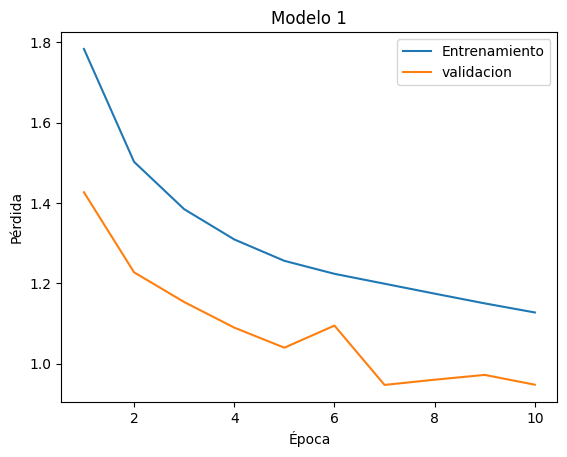

In [42]:
plt.figure()
plt.title("Modelo 1")
plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.plot(epocas_1,historial_1.history["loss"],label="Entrenamiento")
plt.plot(epocas_1,historial_1.history["val_loss"],label="validacion") 
plt.legend()

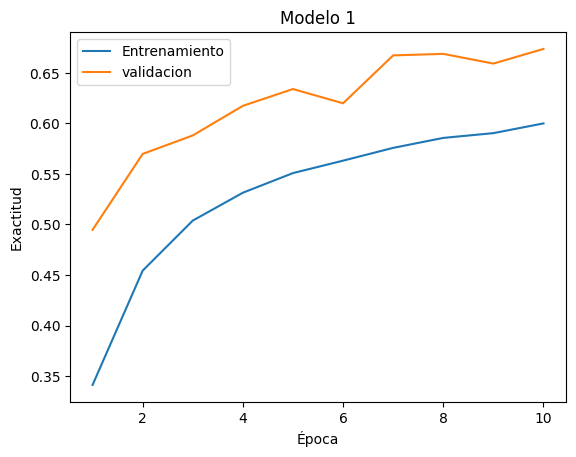

In [43]:
plt.figure()
plt.title("Modelo 1")
plt.xlabel("Época")
plt.ylabel("Exactitud")
plt.plot(epocas_1,historial_1.history["accuracy"],label="Entrenamiento")
plt.plot(epocas_1,historial_1.history["val_accuracy"],label="validacion") 
plt.legend()

In [44]:
epocas_2 = range(1,len(historial_2.history["loss"])+1)

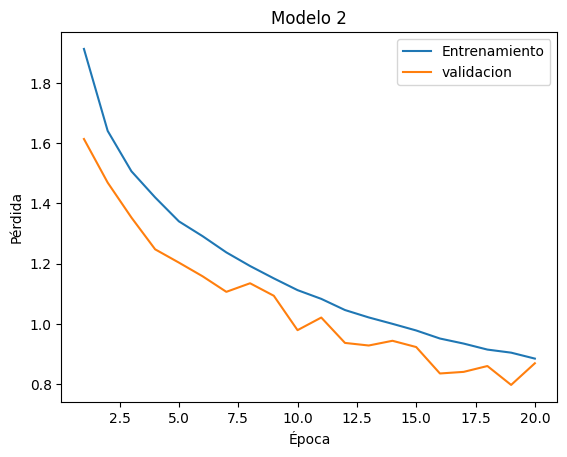

In [45]:
plt.figure()
plt.title("Modelo 2")
plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.plot(epocas_2,historial_2.history["loss"],label="Entrenamiento")
plt.plot(epocas_2,historial_2.history["val_loss"],label="validacion") 
plt.legend()

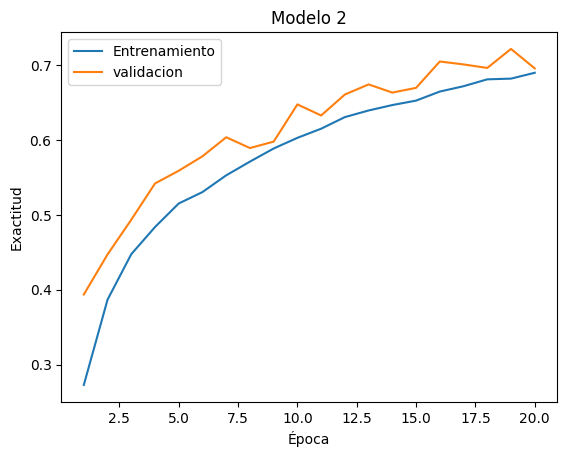

In [46]:
plt.figure()
plt.title("Modelo 2")
plt.xlabel("Época")
plt.ylabel("Exactitud")
plt.plot(epocas_2,historial_2.history["accuracy"],label="Entrenamiento")
plt.plot(epocas_2,historial_2.history["val_accuracy"],label="validacion")  
plt.legend()

In [47]:
epocas_3 = range(1,len(historial_3.history["loss"])+1)

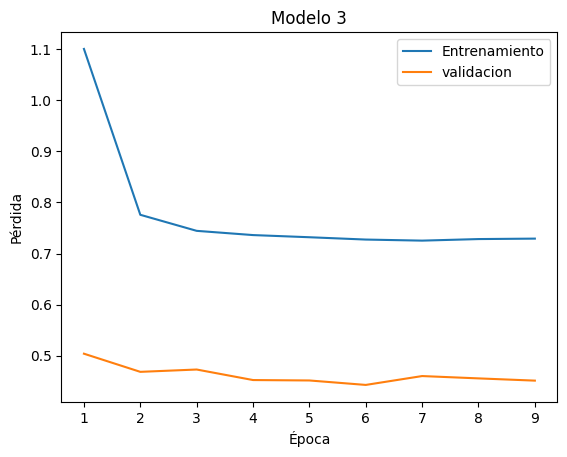

In [48]:
plt.figure()
plt.title("Modelo 3")
plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.plot(epocas_3,historial_3.history["loss"],label="Entrenamiento")
plt.plot(epocas_3,historial_3.history["val_loss"],label="validacion")
plt.legend()

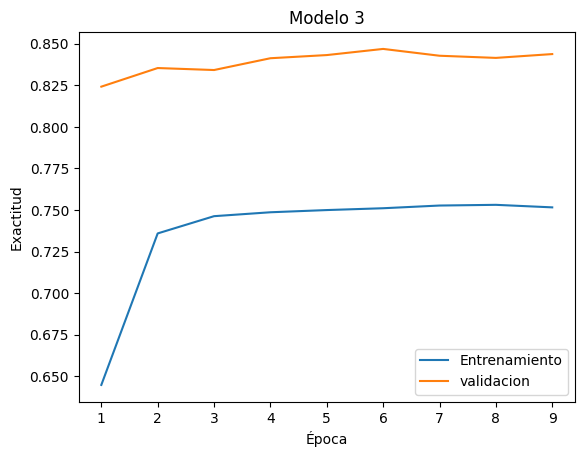

In [49]:
plt.figure()
plt.title("Modelo 3")
plt.xlabel("Época")
plt.ylabel("Exactitud")
plt.plot(epocas_3,historial_3.history["accuracy"],label="Entrenamiento")
plt.plot(epocas_3,historial_3.history["val_accuracy"],label="validacion") 
plt.legend()

In [55]:
modelo.save("modelo_1.keras")
modelo2.save("modelo_2.keras")
modelo3.save("modelo_3.keras")

In [50]:
resultados_1 = modelo.evaluate(x_test, y_test, batch_size=64, return_dict=True)

157/157 [==============================] - 6s 24ms/step - loss: 0.9417 - accuracy: 0.6714


In [51]:
resultados_2 = modelo2.evaluate(x_test, y_test, batch_size=64, return_dict=True)

157/157 [==============================] - 6s 32ms/step - loss: 0.8728 - accuracy: 0.6979


In [52]:
resultados_3 = modelo3.evaluate(x_test, y_test, batch_size=64, return_dict=True)

157/157 [==============================] - 44s 274ms/step - loss: 0.4516 - accuracy: 0.8445


# Conclusiones.

Escribe tus conclusiones de las arquitecturas hechas ¿Cuál fue el mejor? ¿Por qué? ¿Qué mejoraría? ¿Cómo lo mejoraría?

| Modelo | Exactitud test | Pérdida test | Parámetros totales | Entrenables | Entrenamiento |
|---|---:|---:|---:|---:|---:|
| CNN 1 | 67.14 % | 0.9417 | 545,098 | 545,098 | 7.29 min |
| CNN 2 | 69.79 % | 0.8728 | 111,050 | 111,050 | 16.05 min |
| MobileNetV2 | **84.45 %** | **0.4516** | 2,270,794 | 12,810 | 30.43 min |

La mejor fue MobileNetV2, tuvo la mejor precicion asi como la menor perdida, si dependiera de mi quiza mejoraria el tiempo de entrenamiento ya que fue el que se tardo mas pero supongo eso depende del hardware de la computadora que se utilice, quiza añadir una capas intermedia mas para mejorar un poco pero no le cambiara mucho ya que tuvo una buena presicion